### Import dependencies

In [1]:
from pydantic import BaseModel, Field

from qdrant_client import QdrantClient
from qdrant_client.models import Prefetch, Filter, FieldCondition, MatchText, FusionQuery, Document


from langsmith import traceable, get_current_run_tree

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.types import Send, Command

from langchain_core.messages import AIMessage, ToolMessage

from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List, Optional, Sequence
from IPython.display import Image, display
from operator import add
from openai import OpenAI
from superlinked import framework as sl
from api.agents.superlinked_app.index import business_index, business
from api.agents.superlinked_app.query import query
from api.agents.superlinked_app.utils.utils import *

import openai

import random
import ast
import inspect
import instructor
import json
import os

/Users/wilfriedtcheumaha/Code/yelp-assistant/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


01:57:34 sentence_transformers.SentenceTransformer INFO   Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1245.16it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


01:57:34 superlinked.framework.common.space.embedding.model_based.embedding_engine_manager INFO   Consider caching model dimension.
01:57:34 superlinked.framework.dsl.index.index INFO   initialized index


In [2]:
qdrant_vdb = sl.QdrantVectorDatabase(
    url="http://localhost:6333",
    # Superlinked's QdrantVectorDatabase currently requires an api_key arg.
    # For local Qdrant this is typically unused, so we default to empty.
    api_key=os.getenv("QDRANT_API_KEY", ""),
)
parser = sl.DataFrameParser(business)

source_qdrant = sl.RestSource(
    business,
    parser=parser,
)

# RestExecutor needs sl.RestQuery (path for /api/v1/search/<query_path> by default).
business_rest_query = sl.RestQuery(
    rest_descriptor=sl.RestDescriptor(query_path="business_search"),
    query_descriptor=query,
)

executor_qdrant = sl.RestExecutor(
    sources=[source_qdrant],
    indices=[business_index],
    vector_database=qdrant_vdb,
    queries=[business_rest_query],
)
qdrant_app = executor_qdrant.run()


def Retrieve_context(question, qdrant_app, k=5):
    qdrant_results = qdrant_app.query(
        query,
        natural_query=question,
        limit=k,
    )

    format_minute_columns_to_hhmm(sl.PandasConverter.to_pandas(qdrant_results))

    return {
        "retrived_restaurant_ids":[e.id for e in qdrant_results.entries],
        "retrived_restaurants_names":[e.fields.get("name") for e in qdrant_results.entries],
        "retrived_restaurants_ratings":[e.fields.get("stars") for e in qdrant_results.entries],
        "retrived_restaurants_reviews_count":[e.fields.get("review_count") for e in qdrant_results.entries],
        "retrived_states":[e.fields.get("state") for e in qdrant_results.entries],
        "retrived_cities":[e.fields.get("city") for e in qdrant_results.entries],
        "similarity_scores":[e.metadata.score for e in qdrant_results.entries],
    }


    

/Users/wilfriedtcheumaha/Code/yelp-assistant/.venv/lib/python3.12/site-packages/superlinked/framework/storage/qdrant/qdrant_vdb_connector.py:87: UserWarning: Api key is used with an insecure connection.
  self._client = AsyncQdrantClient(
/Users/wilfriedtcheumaha/Code/yelp-assistant/.venv/lib/python3.12/site-packages/superlinked/framework/storage/qdrant/qdrant_vdb_connector.py:92: UserWarning: Api key is used with an insecure connection.
  self._sync_client = QdrantClient(


01:57:38 superlinked.framework.query.query_dag_evaluator INFO   initialized query dag
01:57:38 superlinked.framework.online.online_dag_evaluator INFO   initialized entity dag


### Query expansion (Parrallel execution)

In [3]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[dict], add] = []
    question_relevant: bool = False
    initial_query: str = ""
    answer: str = ""
    query: str = ""
    k: int = 10

### Query expansion/ Rewriting Node

In [15]:
class QueryExpandResponse(BaseModel):
   expanded_query: List[str]

In [16]:
@traceable(
    name="query_expand_node",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def query_expand_node(state: State) -> dict:

   prompt_template =  """You are part of a shopping assistant that can answer questions about restaurants.

Instructions:
- You will be given a question and you need to expand it into a list of statements that can be used in contextual search to retrieve relevant restaurants.
- The statements should not overlap in context.
- The answer to the question should contain detailed information about the restaurant and returned with detailed specification in bullet points.

<Question>
{{ query }}
</Question>
"""

   template = Template(prompt_template)
   
   prompt = template.render(
      query=state.initial_query
   )

   client = instructor.from_openai(OpenAI())

   response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=QueryExpandResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
   )

   return {
      "expanded_query": response.expanded_query
   }

In [5]:
def query_expand_conditional_edges(state: State):

    send_messages = []

    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retrieve_node",
                {
                    "query": query,
                    "k": 10
                }
            )
        )

    return send_messages

### Retriever Node

In [6]:
@traceable(
    name="retriever_top_n",
    run_type="retriever",
    )
def retrieve_node(state: State) -> dict:
    qdrant_results = qdrant_app.query(
        query,
        natural_query=state["query"],
        limit=state["k"],
    )

    format_minute_columns_to_hhmm(sl.PandasConverter.to_pandas(qdrant_results))

    return {
        "retrieved_context": [{
            "retrived_restaurant_ids":[e.id for e in qdrant_results.entries],
            "retrived_restaurants_names":[e.fields.get("name") for e in qdrant_results.entries],
            "retrived_restaurants_ratings":[e.fields.get("stars") for e in qdrant_results.entries],
            "retrived_restaurants_reviews_count":[e.fields.get("review_count") for e in qdrant_results.entries],
            "retrived_states":[e.fields.get("state") for e in qdrant_results.entries],
            "retrived_cities":[e.fields.get("city") for e in qdrant_results.entries],
            "similarity_scores":[e.metadata.score for e in qdrant_results.entries],
        }],
    }


    

### Aggregator Node


In [7]:
class AggregatorResponse(BaseModel):
    answer: str= Field(description="The answer to the question")

    
    

In [8]:
@traceable(
   name="aggregator_node",
   run_type="llm",
   metadata={"ls_provider":"openai", "ls_model_name":"gpt-4.1-mini"}
   )
def aggregator_node(state:State) -> dict:
   preprocessed_context = "\n".join(json.dumps(ctx) for ctx in state.retrieved_context)

   prompt_template =  """You are a shopping assistant that can answer questions about the restaurants in the context.

You will be given a question and a list of context.

Instructions:
- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

Context:
{{ preprocessed_context }}

Question:
{{ question }}
"""

   template = Template(prompt_template)
   
   prompt = template.render(
      preprocessed_context=preprocessed_context,
      question=state.initial_query
   )

   client = instructor.from_openai(OpenAI())

   response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=AggregatorResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
   )

   return {
      "answer": response.answer
   }

### User Intent Node

In [9]:
class IntentRouterResponse(BaseModel):
    question_relevant: bool
    answer: str

In [10]:
@traceable(
    name="agent_node",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def intent_router_node(state: State):

   prompt_template =  """You are part of a shopping assistant that can answer questions about restaurants.

Instructions:
- You will be given a question and you need to clasify it into relevant or not relevant.
- If the question is not relevant, return False in field "question_relevant" and set "answer" to explanation why it is not relevant.
- If the question is relevant, return True in field "question_relevant" and set "answer" to "".
- You should only answer questions about the restaurants. If the question is not about the restaurants, you should ask for clarification.

<Question>
{{ query }}
</Question>
"""

   template = Template(prompt_template)
   
   prompt = template.render(
      query=state.initial_query
   )

   client = instructor.from_openai(OpenAI())

   response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=IntentRouterResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
   )

   return {
      "question_relevant": response.question_relevant,
      "answer": response.answer
      }

In [11]:
def intent_router_conditional_edges(state: State):

    if state.question_relevant:
        return "query_expand_node"
    else:
        return "end"

### Graph

In [17]:
workflow = StateGraph(State)

workflow.add_node("query_expand_node", query_expand_node)
workflow.add_node("retrieve_node", retrieve_node)
workflow.add_node("aggregator_node", aggregator_node)
workflow.add_node("intent_router_node", intent_router_node)

workflow.add_edge(START, "intent_router_node")
workflow.add_conditional_edges("query_expand_node", query_expand_conditional_edges)
workflow.add_conditional_edges(
    "intent_router_node",
    intent_router_conditional_edges,
    {
        "query_expand_node": "query_expand_node",
        "end": END
    }
)

workflow.add_edge("retrieve_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

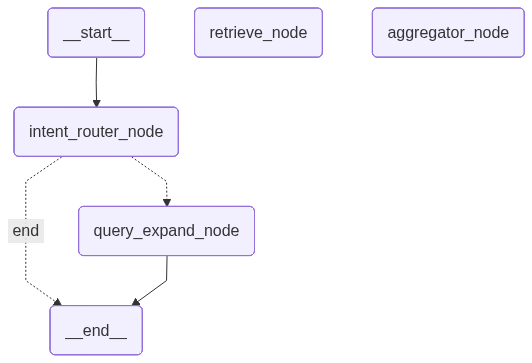

In [18]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
user_question = "3 popular restaurants in tucson and 2 best restaurants in New Orleans"
initial_state = {
    "initial_query": user_question,
}
result = graph.invoke(initial_state)

01:59:22 superlinked.framework.common.delayed_evaluator INFO   Processed sentence-transformers/all-MiniLM-L6-v2 embed
01:59:22 superlinked.framework.common.delayed_evaluator INFO   Processed sentence-transformers/all-MiniLM-L6-v2 embed
01:59:22 superlinked.framework.common.delayed_evaluator INFO   Processed sentence-transformers/all-MiniLM-L6-v2 embed
01:59:22 superlinked.framework.query.query_dag_evaluator INFO   evaluated query
01:59:22 superlinked.framework.query.query_dag_evaluator INFO   evaluated query
01:59:22 superlinked.framework.query.query_dag_evaluator INFO   evaluated query
01:59:23 superlinked.framework.dsl.executor.query.query_executor INFO   executed query
01:59:23 superlinked.framework.dsl.executor.query.query_executor INFO   executed query
01:59:23 superlinked.framework.dsl.executor.query.query_executor INFO   executed query
01:59:26 superlinked.framework.common.delayed_evaluator INFO   Processed sentence-transformers/all-MiniLM-L6-v2 embed
01:59:26 superlinked.framew

In [20]:
result

{'expanded_query': ['popular restaurants in Tucson',
  'top-rated restaurants in Tucson',
  'best dining places in Tucson',
  'best restaurants in New Orleans',
  'top restaurants in New Orleans'],
 'retrieved_context': [{'retrived_restaurant_ids': ['ZHcfV3d7ZW8bmwgKCsz-RA',
    'tV46IhCfHbsx_af-pMupiw',
    'IKMAgK2m6WRIViVFB2vAFQ',
    'L1TzHZ8OXfVXTfyzidstzg',
    '4jkH3istYst8zxLxb-QVmg',
    'cGHRiW3ObFO1eOMUTBBM_Q',
    'ltmenUcFgNv7fPOU2BiwKw',
    'XR6zkgsFiwnaH2FVkoUVAQ',
    'zL7wVx6Ihf1VEb9Wi7P0bw',
    'D44IBRDtEScaWELey5IfCA'],
   'retrived_restaurants_names': ['Pizza Luna',
    'Cafe Poca Cosa',
    'Miss Saigon',
    'Snooze An AM Eatery',
    'La Parrilla Suiza',
    'Taegukgi',
    'El Minuto Cafe',
    'American Eat Company',
    'Beaut Burger',
    "May's Counter Chicken And Waffles"],
   'retrived_restaurants_ratings': [4.5,
    4.0,
    4.0,
    4.5,
    3.0,
    4.0,
    3.5,
    4.0,
    4.0,
    3.5],
   'retrived_restaurants_reviews_count': [251,
    1306,
    

In [21]:
print(result["answer"])

Popular restaurants in Tucson:
1. Pizza Luna
   - Rating: 4.5
   - Reviews: 251
2. Cafe Poca Cosa
   - Rating: 4.0
   - Reviews: 1306
3. Miss Saigon
   - Rating: 4.0
   - Reviews: 702

Best restaurants in New Orleans:
1. Ruby Slipper - New Orleans
   - Rating: 4.5
   - Reviews: 5193
2. The Governor
   - Rating: 4.5
   - Reviews: 330


In [22]:
initial_state = {
    "initial_query": "Whats the weather today?"
}
result = graph.invoke(initial_state)

In [23]:
result

{'retrieved_context': [],
 'question_relevant': False,
 'initial_query': 'Whats the weather today?',
 'answer': 'The question is about the weather, which is not related to restaurants. Please ask questions specifically about restaurants.'}